# Experiment 8 — 114 Surahs as Separate Authors, Well-Documented Poets Only

Completes the comparison grid alongside Experiment 7. Same well-documented
poet filter as before (total output > 286 verses, the largest surah) —
but here each surah is its own separate author again (like the original
Experiment 2), not the Quran as one combined entity.

| | All 260 poets | Well-documented poets only |
|---|---|---|
| Quran as ONE author | Experiment 1 | Experiment 7 |
| 114 surahs as SEPARATE authors | Experiment 2 | **Experiment 8 (this notebook)** |

**If the sample-size explanation holds**, restricting to well-documented
poets here should also shrink the mixed-cluster percentage (which was
26% with all poets, and rose to 39% when restricted to MINOR poets
earlier). If it doesn't shrink, or grows again, that's more evidence
against the sample-size explanation.

**Embeddings are cached** — reuses `embed_cache/` from earlier runs if
this notebook sits in the same folder, skipping straight to clustering.

**Before you start:** put `poems.db` in the same folder as this
notebook.

Run cells top to bottom, **Shift+Enter**.

In [1]:
# CELL 1 -- Install packages
!pip -q install sentence-transformers torch scikit-learn umap-learn hdbscan pandas numpy matplotlib seaborn scipy requests


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# CELL 2 -- Configuration
import re, sqlite3, hashlib, json, warnings, pickle
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

warnings.filterwarnings("ignore")

DB_PATH = Path("poems.db")
CACHE_DIR = Path("quran_cache"); CACHE_DIR.mkdir(exist_ok=True)
EMBED_CACHE_DIR = Path("embed_cache"); EMBED_CACHE_DIR.mkdir(exist_ok=True)
FIGURES_DIR = Path("output/figures"); FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR = Path("output/tables"); TABLES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR = Path("output/reports"); REPORTS_DIR.mkdir(parents=True, exist_ok=True)

SBERT_MODEL_NAME = "akhooli/Arabic-SBERT-100K"
MAX_VERSES_PER_POEM = 20

UMAP_N_NEIGHBORS = 15
UMAP_MIN_DIST = 0.1
UMAP_N_COMPONENTS_HIGH = 50
UMAP_METRIC = "cosine"
HDBSCAN_MIN_CLUSTER_SIZE = 5
HDBSCAN_MIN_SAMPLES = 3

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
import torch
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
    print("GPU available:", torch.cuda.get_device_name(0))
else:
    print("No GPU found -- will run on CPU (slower).")

def split_verses(poem_text):
    if not poem_text or not isinstance(poem_text, str):
        return []
    verses = re.split(r'[\n\r]+|[.!\u061F?\u061B;]+', poem_text)
    return [v.strip() for v in verses if len(v.strip()) > 10]

plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 300, "savefig.bbox": "tight", "font.size": 11})
print("Config loaded.")

GPU available: NVIDIA GeForce RTX 4080 SUPER
Config loaded.


In [3]:
# CELL 3 -- Load the 260 poets from poems.db
conn = sqlite3.connect(str(DB_PATH))
df = pd.read_sql_query(
    "SELECT poet_name, poem_title, poem_text, poem_type, poem_meter, verses_count "
    "FROM poems WHERE poet_name IS NOT NULL AND poem_text IS NOT NULL "
    "AND LENGTH(poem_text) >= 50",
    conn,
)
conn.close()

df["poem_hash"] = df["poem_text"].apply(lambda t: hashlib.md5(t.strip().encode("utf-8")).hexdigest())
df = df.drop_duplicates(subset=["poem_hash"]).copy()

poems_by_poet = defaultdict(list)
for _, row in df.iterrows():
    poems_by_poet[row["poet_name"]].append(row["poem_text"])
poems_by_poet = dict(poems_by_poet)

poet_total_verses = {
    poet: sum(len(split_verses(p)) for p in poems)
    for poet, poems in poems_by_poet.items()
}

print(f"Poets loaded: {len(poems_by_poet)}")
print(f"Poems loaded: {len(df)}")

Poets loaded: 260
Poems loaded: 2328


In [4]:
# CELL 4 -- Fetch Quran text + per-surah size metadata
cache_file = CACHE_DIR / "quran_ayat.json"

if cache_file.exists():
    print("Loading Quran from local cache...")
    with open(cache_file, encoding="utf-8") as f:
        surahs_raw = json.load(f)
else:
    print("Fetching Quran from Al Quran Cloud API...")
    resp = requests.get("https://api.alquran.cloud/v1/quran/quran-uthmani", timeout=60)
    resp.raise_for_status()
    surahs_raw = resp.json()["data"]["surahs"]
    with open(cache_file, "w", encoding="utf-8") as f:
        json.dump(surahs_raw, f, ensure_ascii=False)
    print("Fetched and cached.")

surah_names = {}
surah_poem_text = {}
for s in surahs_raw:
    snum = s["number"]
    surah_names[snum] = s["englishName"]
    ayat_texts = [a["text"] for a in s["ayahs"]]
    surah_poem_text[snum] = "\n".join(ayat_texts)

surah_verse_count = {snum: len(split_verses(text)) for snum, text in surah_poem_text.items()}

print(f"Surahs loaded: {len(surah_poem_text)}")
print(f"Surah verse-count range: {min(surah_verse_count.values())} to {max(surah_verse_count.values())}")

Fetching Quran from Al Quran Cloud API...
Fetched and cached.
Surahs loaded: 114
Surah verse-count range: 3 to 286


In [5]:
# CELL 5 -- Embed the 260 poets (cached after first run)
from sentence_transformers import SentenceTransformer

poet_cache_file = EMBED_CACHE_DIR / "poet_embeddings.pkl"

print("Loading model:", SBERT_MODEL_NAME)
model = SentenceTransformer(SBERT_MODEL_NAME)
print("Loaded. Embedding dim:", model.get_sentence_embedding_dimension())

def _encode(texts, batch_size=64):
    if not texts:
        return np.array([])
    return model.encode(texts, batch_size=batch_size, show_progress_bar=False,
                         normalize_embeddings=True, convert_to_numpy=True)

def embed_poem_verse_average(poems_by_author, max_verses=MAX_VERSES_PER_POEM, seed=RANDOM_SEED):
    out = {}
    rng = np.random.RandomState(seed)
    for author, poems in poems_by_author.items():
        poem_vectors = []
        for poem in poems:
            verses = split_verses(poem)
            if len(verses) > max_verses:
                idx = rng.choice(len(verses), max_verses, replace=False)
                verses = [verses[i] for i in sorted(idx)]
            if verses:
                poem_vectors.append(np.mean(_encode(verses), axis=0))
        if poem_vectors:
            out[author] = np.mean(poem_vectors, axis=0)
    return out

if poet_cache_file.exists():
    print("Loading cached poet embeddings...")
    with open(poet_cache_file, "rb") as f:
        poet_embeddings = pickle.load(f)
    print(f"Loaded {len(poet_embeddings)} cached poet embeddings.")
else:
    print("Embedding 260 poets (this is the slow step, one-time only)...")
    poet_embeddings = embed_poem_verse_average(poems_by_poet)
    with open(poet_cache_file, "wb") as f:
        pickle.dump(poet_embeddings, f)
    print(f"Done and cached. {len(poet_embeddings)} poets embedded.")

Loading model: akhooli/Arabic-SBERT-100K


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loaded. Embedding dim: 768
Embedding 260 poets (this is the slow step, one-time only)...
Done and cached. 260 poets embedded.


In [6]:
# CELL 6 -- Embed the 114 surahs (cached after first run)
surah_cache_file = EMBED_CACHE_DIR / "surah_vectors.pkl"

if surah_cache_file.exists():
    print("Loading cached surah embeddings...")
    with open(surah_cache_file, "rb") as f:
        surah_vectors = pickle.load(f)
    print(f"Loaded {len(surah_vectors)} cached surah embeddings.")
else:
    print("Embedding 114 surahs...")
    surah_vectors = {}
    for snum, poem_text in surah_poem_text.items():
        verses = split_verses(poem_text)
        if verses:
            surah_vectors[snum] = np.mean(_encode(verses), axis=0)
    with open(surah_cache_file, "wb") as f:
        pickle.dump(surah_vectors, f)
    print(f"Done and cached. {len(surah_vectors)} surahs embedded.")

print(f"{len(surah_vectors)} surah vectors ready.")

Embedding 114 surahs...
Done and cached. 114 surahs embedded.
114 surah vectors ready.


## Filter to well-documented poets, then cluster surahs (as separate authors) alongside them

In [7]:
# CELL 7 -- Filter to well-documented poets, cluster 114 surahs (separate) + them
import umap, hdbscan
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score

def run_umap(matrix, n_components, n_neighbors, min_dist, metric="cosine", random_state=RANDOM_SEED):
    reducer = umap.UMAP(n_neighbors=min(n_neighbors, len(matrix) - 1), n_components=n_components,
                         min_dist=min_dist, metric=metric, random_state=random_state)
    return reducer.fit_transform(matrix)

def cluster_and_report(embeddings_dict, label_types, title, n_neighbors=UMAP_N_NEIGHBORS,
                       min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE, verbose=True):
    names = sorted(embeddings_dict.keys())
    n = len(names)
    emb_matrix = np.array([embeddings_dict[nm] for nm in names])

    # n-2 safety margin: UMAP's spectral init needs n_components strictly
    # less than n_samples-1, or it hits a scipy eigensolver error on
    # small-ish datasets.
    umap_high = run_umap(emb_matrix, min(UMAP_N_COMPONENTS_HIGH, max(2, n - 2)), n_neighbors, 0.0, UMAP_METRIC)
    clusterer = hdbscan.HDBSCAN(min_cluster_size=min(min_cluster_size, max(2, n // 10)),
                                min_samples=HDBSCAN_MIN_SAMPLES,
                                cluster_selection_method="eom", metric="euclidean")
    labels = clusterer.fit_predict(umap_high)
    umap_2d = run_umap(emb_matrix, 2, n_neighbors, UMAP_MIN_DIST, UMAP_METRIC)

    mask = labels >= 0
    n_clusters = len(set(labels[mask])) if mask.sum() > 0 else 0
    n_outliers = int(np.sum(labels == -1))
    sil = float(silhouette_score(umap_high[mask], labels[mask])) if n_clusters >= 2 and mask.sum() > n_clusters else None

    result_df = pd.DataFrame({
        "name": names, "type": [label_types[nm] for nm in names],
        "cluster": labels, "umap_x": umap_2d[:, 0], "umap_y": umap_2d[:, 1],
    })
    if verbose:
        print(f"=== {title} ===")
        print(f"Total: {n} | Clusters: {n_clusters} | Outliers: {n_outliers} | Silhouette: {sil}")
    return result_df, {"n_entities": n, "n_clusters": n_clusters, "n_outliers": n_outliers, "silhouette": sil}

# Same threshold as Experiment 7: total verses > largest surah (286)
max_surah_verses = max(surah_verse_count.values())
large_poets = {p: v for p, v in poet_total_verses.items() if v > max_surah_verses}
print(f"Well-documented poets (total verses > {max_surah_verses}): {len(large_poets)} of {len(poet_total_verses)}")

exp8_embeddings = {p: poet_embeddings[p] for p in large_poets if p in poet_embeddings}
for snum, vec in surah_vectors.items():
    exp8_embeddings[f"Surah {snum}: {surah_names[snum]}"] = vec
exp8_types = {nm: ("Surah" if nm.startswith("Surah ") else "Poet") for nm in exp8_embeddings}

exp8_df, exp8_metrics = cluster_and_report(
    exp8_embeddings, exp8_types,
    f"Experiment 8: {len(large_poets)} well-documented poets + 114 surahs")

cluster_composition8 = exp8_df.groupby("cluster")["type"].value_counts().unstack(fill_value=0)
print("\nCluster composition (poets vs surahs per cluster):")
print(cluster_composition8)

surah_only8 = cluster_composition8[(cluster_composition8.get("Poet", 0) == 0) & (cluster_composition8.index != -1)]
mixed8 = cluster_composition8[(cluster_composition8.get("Poet", 0) > 0) & (cluster_composition8.get("Surah", 0) > 0)]
surah_rows8 = exp8_df[exp8_df["type"] == "Surah"]
surah_outliers8 = surah_rows8[surah_rows8["cluster"] == -1]
surahs_in_mixed8 = sum(cluster_composition8.loc[mixed8.index, "Surah"]) if len(mixed8) > 0 else 0

print(f"\nSurah-only clusters: {len(surah_only8)}")
print(f"Mixed clusters (poets + surahs): {len(mixed8)}")
print(f"Surahs in mixed clusters: {surahs_in_mixed8} / {len(surah_rows8)} ({surahs_in_mixed8/len(surah_rows8)*100:.1f}%)")
print(f"Surahs as outliers: {len(surah_outliers8)} / {len(surah_rows8)}")

if len(mixed8) > 0:
    print("\nMixed clusters -- which poets share a cluster with surahs:")
    for cl in mixed8.index:
        members = exp8_df[exp8_df["cluster"] == cl]
        poets_in = members[members["type"] == "Poet"]["name"].tolist()
        n_surahs_in = len(members[members["type"] == "Surah"])
        print(f"  Cluster {cl}: {n_surahs_in} surahs with poets: {poets_in}")

exp8_df.to_csv(TABLES_DIR / "experiment8_clusters.csv", index=False)

Well-documented poets (total verses > 286): 35 of 260
=== Experiment 8: 35 well-documented poets + 114 surahs ===
Total: 149 | Clusters: 9 | Outliers: 3 | Silhouette: 0.679192304611206

Cluster composition (poets vs surahs per cluster):
type     Poet  Surah
cluster             
-1          0      3
 0         35      0
 1          0     22
 2          0     10
 3          0     26
 4          0      8
 5          0     22
 6          0      7
 7          0      6
 8          0     10

Surah-only clusters: 8
Mixed clusters (poets + surahs): 0
Surahs in mixed clusters: 0 / 114 (0.0%)
Surahs as outliers: 3 / 114


In [8]:
# CELL 8 -- Compare against the original Experiment 2 (all 260 poets)
comparison_rows = [
    {"variant": "All 260 poets + 114 surahs (original Exp 2)", "n_poets": 260,
     "surahs_in_mixed_clusters": "30 / 114 (26%)", "surahs_as_outliers": "1 / 114",
     "silhouette": "0.469"},
    {"variant": f"{len(large_poets)} well-documented poets + 114 surahs (this run)", "n_poets": len(large_poets),
     "surahs_in_mixed_clusters": f"{surahs_in_mixed8} / {len(surah_rows8)} ({surahs_in_mixed8/len(surah_rows8)*100:.0f}%)",
     "surahs_as_outliers": f"{len(surah_outliers8)} / {len(surah_rows8)}",
     "silhouette": f"{exp8_metrics['silhouette']:.3f}" if exp8_metrics['silhouette'] else "n/a"},
]
comparison_df8 = pd.DataFrame(comparison_rows)
comparison_df8.to_csv(TABLES_DIR / "experiment8_comparison.csv", index=False)
print(comparison_df8.to_string(index=False))

                                         variant  n_poets surahs_in_mixed_clusters surahs_as_outliers silhouette
     All 260 poets + 114 surahs (original Exp 2)      260           30 / 114 (26%)            1 / 114      0.469
35 well-documented poets + 114 surahs (this run)       35             0 / 114 (0%)            3 / 114      0.679


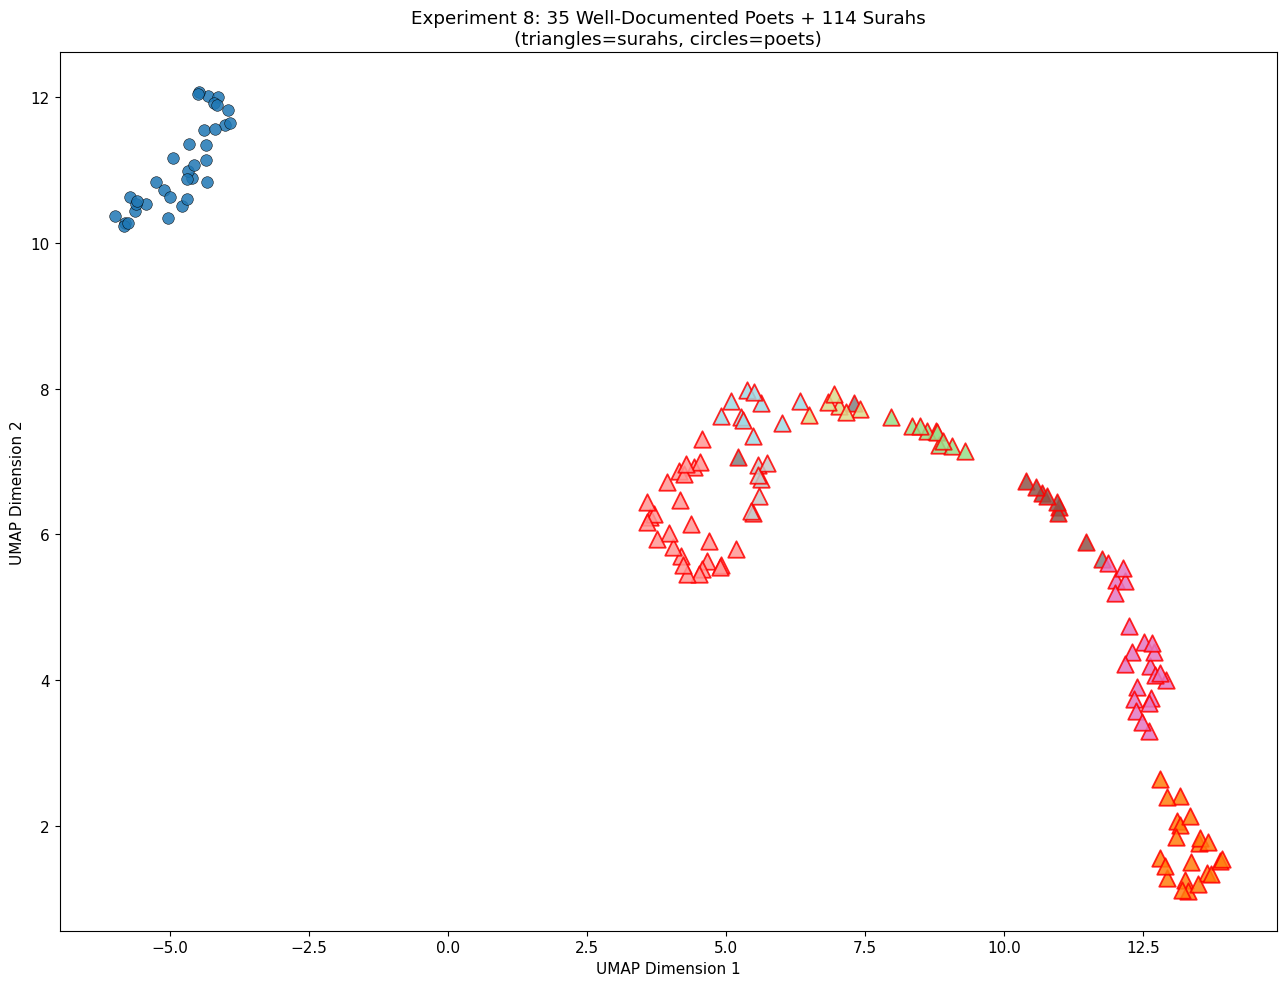

Figure saved.


In [9]:
# CELL 9 -- Figure
fig, ax = plt.subplots(figsize=(13, 10))
unique_clusters = sorted(exp8_df["cluster"].unique())
n_clust_plot = len([c for c in unique_clusters if c >= 0])
colors = plt.cm.tab20(np.linspace(0, 1, max(n_clust_plot, 1)))

for cl in unique_clusters:
    sub = exp8_df[exp8_df["cluster"] == cl]
    for t, marker, size, edge, lw in [("Poet", "o", 70, "black", 0.4), ("Surah", "^", 140, "red", 1.3)]:
        tsub = sub[sub["type"] == t]
        if len(tsub) == 0:
            continue
        color = "gray" if cl == -1 else colors[cl % len(colors)]
        ax.scatter(tsub["umap_x"], tsub["umap_y"], c=[color], marker=marker, s=size,
                  alpha=0.85, edgecolors=edge, linewidth=lw)

ax.set_xlabel("UMAP Dimension 1"); ax.set_ylabel("UMAP Dimension 2")
ax.set_title(f"Experiment 8: {len(large_poets)} Well-Documented Poets + 114 Surahs\n(triangles=surahs, circles=poets)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "experiment8_umap.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved.")

In [10]:
# CELL 10 -- Final report
report_path = REPORTS_DIR / "experiment8_report.txt"
with open(report_path, "w", encoding="utf-8") as f:
    f.write("=" * 70 + "\n")
    f.write("EXPERIMENT 8: WELL-DOCUMENTED POETS + 114 SEPARATE SURAHS\n")
    f.write("=" * 70 + "\n\n")

    f.write("METHOD\n" + "-" * 40 + "\n")
    f.write(f"  Threshold: total verses > {max_surah_verses} (largest surah's verse count)\n")
    f.write(f"  Well-documented poets: {len(large_poets)} of {len(poet_total_verses)}\n")
    f.write(f"  Each of the 114 surahs entered as its own separate author\n\n")

    f.write("RESULT\n" + "-" * 40 + "\n")
    for k, v in exp8_metrics.items():
        f.write(f"  {k}: {v}\n")
    f.write(f"  Surah-only clusters: {len(surah_only8)}\n")
    f.write(f"  Mixed clusters (poets + surahs): {len(mixed8)}\n")
    f.write(f"  Surahs in mixed clusters: {surahs_in_mixed8} / {len(surah_rows8)} "
            f"({surahs_in_mixed8/len(surah_rows8)*100:.1f}%)\n")
    f.write(f"  Surahs as outliers: {len(surah_outliers8)} / {len(surah_rows8)}\n")

    f.write("\nCOMPARISON: ALL POETS vs. WELL-DOCUMENTED POETS ONLY\n" + "-" * 40 + "\n")
    f.write(comparison_df8.to_string(index=False) + "\n")

    f.write("\nHOW TO READ THIS\n" + "-" * 40 + "\n")
    f.write("  Same logic as Experiment 7. If restricting to well-documented\n")
    f.write("  poets here also SHRINKS the mixed-cluster percentage (down from\n")
    f.write("  26%), that's a second, independent piece of evidence for the\n")
    f.write("  sample-size explanation. If it stays flat or grows, that's a\n")
    f.write("  second piece of evidence against it -- consistent with what the\n")
    f.write("  minor-poets-only test (which INCREASED to 39%) already suggested.\n")

print(f"Report written to {report_path}")
print()
print(open(report_path, encoding="utf-8").read())

Report written to output\reports\experiment8_report.txt

EXPERIMENT 8: WELL-DOCUMENTED POETS + 114 SEPARATE SURAHS

METHOD
----------------------------------------
  Threshold: total verses > 286 (largest surah's verse count)
  Well-documented poets: 35 of 260
  Each of the 114 surahs entered as its own separate author

RESULT
----------------------------------------
  n_entities: 149
  n_clusters: 9
  n_outliers: 3
  silhouette: 0.679192304611206
  Surah-only clusters: 8
  Mixed clusters (poets + surahs): 0
  Surahs in mixed clusters: 0 / 114 (0.0%)
  Surahs as outliers: 3 / 114

COMPARISON: ALL POETS vs. WELL-DOCUMENTED POETS ONLY
----------------------------------------
                                         variant  n_poets surahs_in_mixed_clusters surahs_as_outliers silhouette
     All 260 poets + 114 surahs (original Exp 2)      260           30 / 114 (26%)            1 / 114      0.469
35 well-documented poets + 114 surahs (this run)       35             0 / 114 (0%)          

## Done

Output in `output/`:
- `output/tables/experiment8_clusters.csv` — full cluster assignment
- `output/tables/experiment8_comparison.csv` — before/after comparison
- `output/figures/experiment8_umap.png` — UMAP scatter
- `output/reports/experiment8_report.txt` — full summary

With this and Experiment 7 both done, you now have the complete 2x2
comparison: Quran-as-one vs. Quran-as-114, each tested against all 260
poets and against well-documented poets only.